Desafio de Detecção de Anomalias em Transações em Python

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/mapti-michel/desafio-dio-python/refs/heads/main/creditcardDataset.csv"

df = pd.read_csv(url)

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,94.0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,...,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,0.442798,1
1,82.0,-0.600639,-0.291694,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,...,0.343618,-1.763040,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280,0.261049,1
2,13.0,-0.839218,-0.309212,0.331263,0.975545,-0.479174,-0.185659,-1.106335,-1.196207,0.812526,...,0.087047,-0.299007,0.091761,-1.987569,-0.219672,0.357113,1.477894,-0.518270,0.343387,1
3,43.0,-0.808494,-0.501757,0.915402,0.328751,-0.529760,0.513267,0.097078,0.968645,-0.702053,...,-0.161286,0.404051,1.886186,0.174578,0.257550,-0.074446,-1.918771,-0.026514,0.834572,1
4,85.0,0.060230,2.463242,-0.192361,0.301547,-0.034712,-1.168678,1.142823,0.751933,0.791032,...,-1.062304,0.473592,-0.919424,1.549934,-0.783253,-0.322062,0.813517,-1.230864,0.935485,1


In [2]:
# Problema de classificação desbalanceada

df["Class"].value_counts(normalize=True)

,proportion
Class,
1,0.6
0,0.4


In [3]:
# Feature Engineering

import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [5]:
# Padronização de dados
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[['Amount']])

In [6]:
from sklearn.model_selection import train_test_split

x = df.drop("Class", axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
)

In [8]:
# Logistic Regression - Modelo de classificação

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.31      0.33      0.32        12
           1       0.53      0.50      0.51        18

    accuracy                           0.43        30
   macro avg       0.42      0.42      0.42        30
weighted avg       0.44      0.43      0.44        30



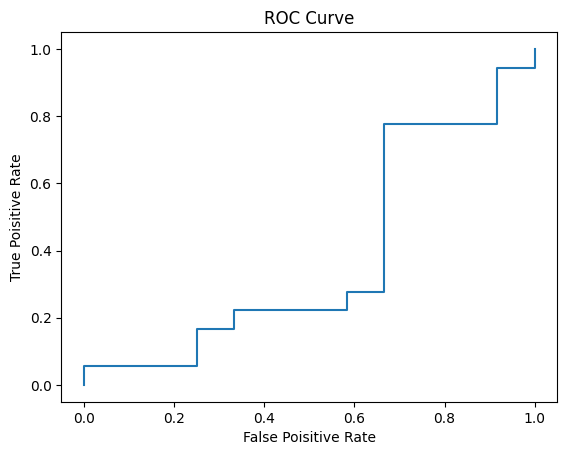

AUC: 0.37962962962962965


In [12]:
# Accuracy

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Poisitive Rate")
plt.ylabel("True Poisitive Rate")

plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

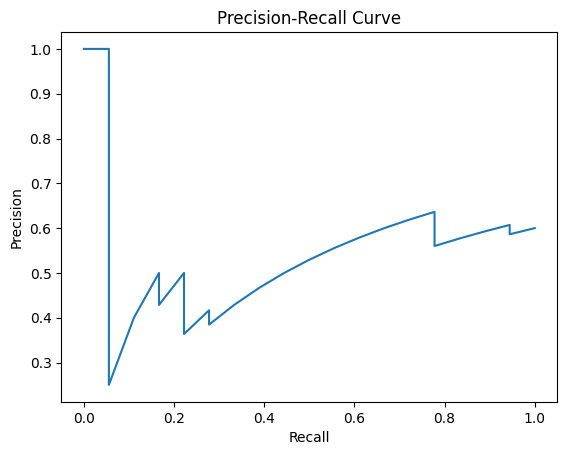

In [14]:
# Método Recall

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [16]:
# Undersampling

fraudes = df[df["Class"] == 1]

normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42, replace=True)

df_under = pd.concat([fraudes, normais])

In [17]:
# Oversampling

from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_res, y_res = smote.fit_resample(x,y)

In [19]:
# Conjunto de árvores de decisão

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.33      0.17      0.22        12
           1       0.58      0.78      0.67        18

    accuracy                           0.53        30
   macro avg       0.46      0.47      0.44        30
weighted avg       0.48      0.53      0.49        30



In [21]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [23]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.44      0.33      0.38        12
           1       0.62      0.72      0.67        18

    accuracy                           0.57        30
   macro avg       0.53      0.53      0.52        30
weighted avg       0.55      0.57      0.55        30



In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10, #ajuda com desblanceamento
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [15:22:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [28]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.38      0.25      0.30        12
           1       0.59      0.72      0.65        18

    accuracy                           0.53        30
   macro avg       0.48      0.49      0.47        30
weighted avg       0.50      0.53      0.51        30



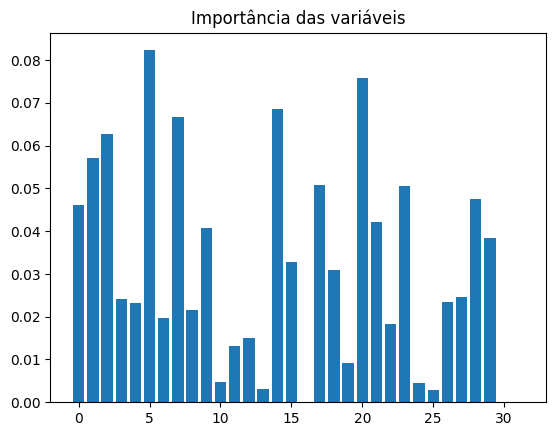

In [29]:
# Ajuda a entender quais variáveis influenciam mais o modelo
import matplotlib.pyplot as plt
importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

In [31]:
# Testamos várias combinações para melhorar o modelo

from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3,5],
    "n_estimators": [50,100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(x_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 3, 'n_estimators': 50}


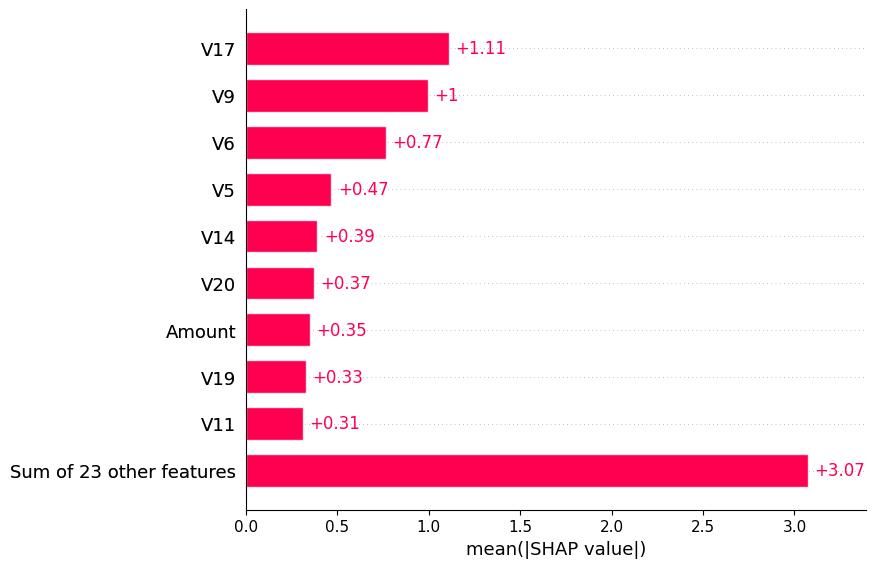

In [32]:
import shap

explainer = shap.Explainer(xgb)

shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)